# Multi-Layer Perceptron: Basketball Player Quality Evaluation
This notebook implements a multi-layer perceptron from scratch using NumPy
to rate the overall quality of a basketball player on a 0-10 scale from five
input ratings: speed, jump, shooting, intelligence, and strength. The
network uses the sigmoid activation in both the hidden and output layers and
produces its rating through forward propagation.

# Section 1: Imports

In [7]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns

In [10]:
# Set a consistent visual style for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Section 2: Network Architecture

The MLP has three layers:

- **Input layer** – 5 nodes, one per player rating (speed, jump, shooting,
  intelligence, strength). Each rating is an integer from 1 to 100.
- **Hidden layer** – 4 nodes (free choice; kept small for a simple
  architecture).
- **Output layer** – 1 node giving the quality score, scaled to the 0-10
  range with one decimal place.

In [11]:
# Layer sizes
input_size = 5    # Five player ratings
hidden_size = 4   # Four hidden nodes
output_size = 1   # One quality score

# Section 3: Activation Function

In [12]:
def sigmoid(x):
    """Sigmoid activation, squashing values into the range (0, 1)."""
    return 1 / (1 + np.exp(-x))

In [13]:
def plot_sigmoid():
    """Plot the sigmoid curve to show its output range."""
    x = np.linspace(-10, 10, 200)
    plt.figure(figsize=(6, 4))
    plt.plot(x, sigmoid(x), color="steelblue", linewidth=2)
    plt.title("Sigmoid Activation Function", fontweight="bold")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.tight_layout()
    plt.savefig("sigmoid.png", bbox_inches="tight")
    plt.show()

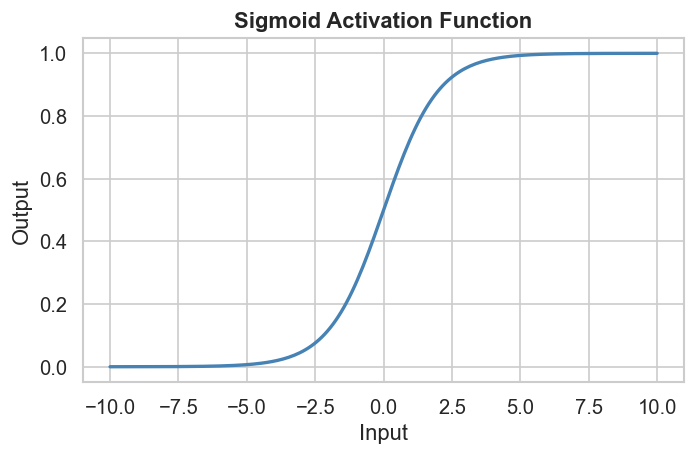

In [14]:
plot_sigmoid()

## Interpretation:
- The sigmoid maps any input to a value between 0 and 1.
- This bounded output is useful for the final layer: the result is scaled
  by 10 to give a quality score in the 0-10 range.
- The same activation is used in the hidden layer to introduce
  non-linearity.

# Section 4: Parameter Initialisation

In [15]:
def initialise_parameters(input_size, hidden_size, output_size, seed=42):
    """
    Initialise random weights and biases for both layers.

    Weights are small random values; biases are small random values close
    to zero, as is typical when initialising a neural network.

    Parameters
    ----------
    input_size, hidden_size, output_size : int
        Number of nodes in each layer.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    dict
        Parameters with keys 'W1', 'b1', 'W2', 'b2'.
    """
    np.random.seed(seed)
    params = {
        "W1": np.random.randn(hidden_size, input_size),   # Input -> hidden
        "b1": np.random.randn(hidden_size),
        "W2": np.random.randn(output_size, hidden_size),  # Hidden -> output
        "b2": np.random.randn(output_size),
    }
    return params

In [16]:
params = initialise_parameters(input_size, hidden_size, output_size)

In [17]:
print("=" * 60)
print("  Parameter Shapes")
print("=" * 60)
for name, value in params.items():
    print(f"  {name}: {value.shape}")

  Parameter Shapes
  W1: (4, 5)
  b1: (4,)
  W2: (1, 4)
  b2: (1,)


# Section 5: Forward Propagation

Forward propagation passes the ratings through the network. The raw ratings
(1-100) are first normalised to 0-1 by dividing by 100, which keeps the
weighted sums in a sensible range so the sigmoid does not saturate. Each
layer computes a weighted sum plus a bias, then applies the sigmoid. The
final 0-1 output is scaled by 10 to give the quality score.

In [18]:
def forward_propagation(inputs, params):
    """
    Run forward propagation and return the quality score (0-10).

    Parameters
    ----------
    inputs : list or np.ndarray
        Five player ratings, each from 1 to 100.
    params : dict
        Network parameters from initialise_parameters.

    Returns
    -------
    float
        Quality score between 0 and 10, rounded to one decimal place.
    """
    x = np.array(inputs) / 100  # Normalise ratings to 0-1

    # Hidden layer: weighted sum + bias, then sigmoid
    z1 = np.dot(params["W1"], x) + params["b1"]
    a1 = sigmoid(z1)

    # Output layer: weighted sum + bias, then sigmoid
    z2 = np.dot(params["W2"], a1) + params["b2"]
    a2 = sigmoid(z2)

    # Scale the 0-1 output to the 0-10 quality range
    return round(float(a2[0]) * 10, 1)

# Section 6: Validation

We pass several sample players through the network to confirm it produces a
valid quality score. Each player is a list of five ratings in the order:
speed, jump, shooting, intelligence, strength.

In [19]:
# Sample players: [speed, jump, shooting, intelligence, strength]
sample_players = [
    [90, 85, 95, 80, 70],
    [40, 55, 30, 60, 45],
    [100, 100, 100, 100, 100],
    [1, 1, 1, 1, 1],
]

In [20]:
print("=" * 60)
print("  Player Quality Predictions")
print("=" * 60)
for i, player in enumerate(sample_players, start=1):
    quality = forward_propagation(player, params)
    print(f"  Player {i}: {player}  ->  quality {quality}")

  Player Quality Predictions
  Player 1: [90, 85, 95, 80, 70]  ->  quality 2.5
  Player 2: [40, 55, 30, 60, 45]  ->  quality 2.4
  Player 3: [100, 100, 100, 100, 100]  ->  quality 2.6
  Player 4: [1, 1, 1, 1, 1]  ->  quality 1.8


## Interpretation:
- Every player receives a valid score between 0 and 10 with one decimal
  place, confirming the forward pass works end to end.
- The scores are clustered and not meaningful predictions because the
  weights and biases are random and untrained.
- The goal of this task is to demonstrate the forward-propagation mechanism
  of a neural network, not to train it. Training with backpropagation would
  be the next step to make the scores reflect real player quality.